In [21]:
import os
import sys

# Print where the notebook is running from (diagnostic)
print("Running from:", os.getcwd())

# Add repo root to path
repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("Added to path:", repo_root)

# Now do the imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data_loader import get_returns
from src.var_historical import historical_var, historical_cvar, var_summary

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Imports OK")

Running from: c:\Users\hardi\var-engine\notebooks
Added to path: c:\Users\hardi\var-engine
Imports OK


In [22]:
TICKER = "NVDA"
START = "2020-01-01"

data = get_returns(TICKER, START)
returns = data['log_return']

print(f"Sample: {len(data)} days, {data.index.min().date()} to {data.index.max().date()}")

Sample: 1605 days, 2020-01-03 to 2026-05-22


In [23]:
summary = var_summary(returns, confidences=(0.95, 0.99), horizons=(1, 10))
print(summary.to_string(index=False))

Confidence  VaR_1d  CVaR_1d  VaR_10d  CVaR_10d
       95%  0.0491   0.0716   0.1551    0.2263
       99%  0.0806   0.1053   0.2548    0.3330


## Interpreting these numbers

Take a $1,000,000 long NVDA position. The table reads:

- 1-day 95% VaR ≈ 4.91% → On 19 out of every 20 days, we expect to lose no more than $XX,000.
- 1-day 99% CVaR ≈ 10.53% → On the worst 1% of days, the AVERAGE loss is $YY,000.

CVaR is strictly larger than VaR at the same confidence — it's the average of the tail, not the boundary. For fat-tailed assets like NVDA, the CVaR–VaR gap is wide. That gap is the tail risk parametric VaR misses.

The 10-day numbers use the √t rule (multiply 1-day by √10). This assumes returns are i.i.d. — which we already showed is false (volatility clusters). The 10-day VaR is therefore a rough approximation, not a forecast. Week 4 GARCH will fix this.

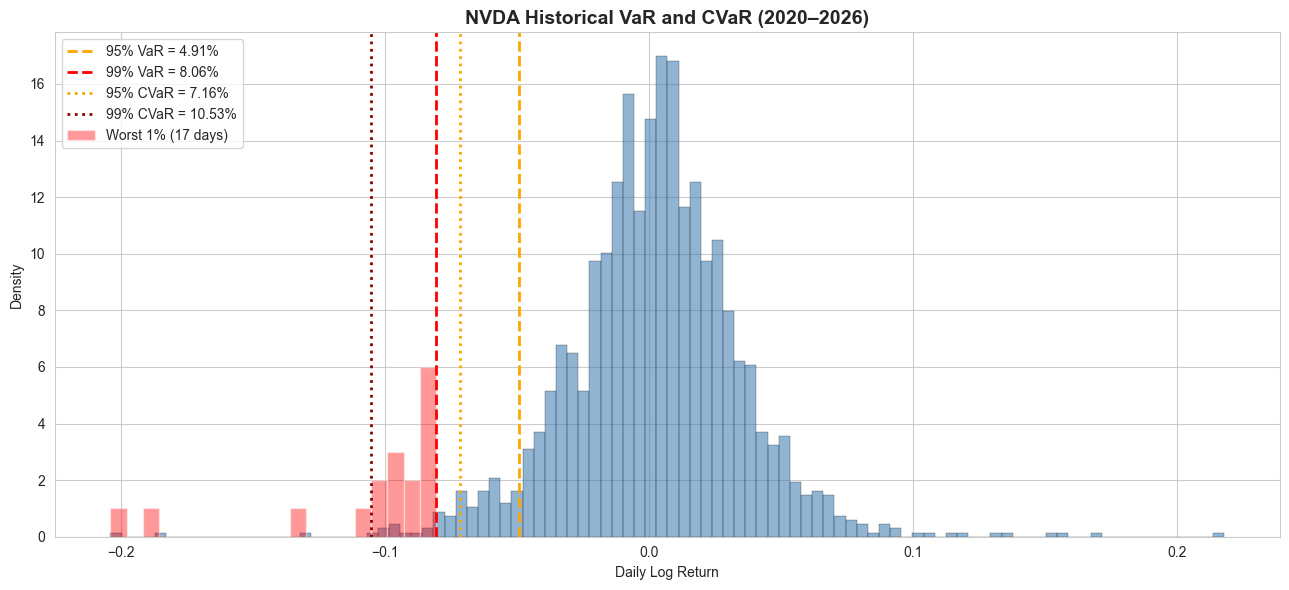

In [24]:
var_95  = historical_var(returns, 0.95)
var_99  = historical_var(returns, 0.99)
cvar_95 = historical_cvar(returns, 0.95)
cvar_99 = historical_cvar(returns, 0.99)

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(returns, bins=100, density=True, alpha=0.6,
        color='steelblue', edgecolor='black', linewidth=0.3)

# VaR lines (boundary of tail)
ax.axvline(-var_95, color='orange', linestyle='--', linewidth=2,
           label=f'95% VaR = {var_95:.2%}')
ax.axvline(-var_99, color='red', linestyle='--', linewidth=2,
           label=f'99% VaR = {var_99:.2%}')

# CVaR lines (average of tail)
ax.axvline(-cvar_95, color='orange', linestyle=':', linewidth=2,
           label=f'95% CVaR = {cvar_95:.2%}')
ax.axvline(-cvar_99, color='darkred', linestyle=':', linewidth=2,
           label=f'99% CVaR = {cvar_99:.2%}')

# Shade the 1% tail
tail_threshold = -var_99
tail = returns[returns <= tail_threshold]
ax.hist(tail, bins=20, density=False, alpha=0.4, color='red',
        label=f'Worst 1% ({len(tail)} days)')

ax.set_title(f'{TICKER} Historical VaR and CVaR (2020–2026)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Density')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/nvda_historical_var.png', dpi=120, bbox_inches='tight')
plt.show()

In [25]:
n = len(returns)
breaches_95 = (returns <= -var_95).sum()
breaches_99 = (returns <= -var_99).sum()

print(f"Total days: {n}")
print(f"95% VaR breaches: {breaches_95} ({breaches_95/n:.2%})  — expected ~5%")
print(f"99% VaR breaches: {breaches_99} ({breaches_99/n:.2%})  — expected ~1%")

Total days: 1605
95% VaR breaches: 81 (5.05%)  — expected ~5%
99% VaR breaches: 17 (1.06%)  — expected ~1%


Key takeaways — Historical VaR on NVDA

1. In-sample breach rates match expected confidence levels (5% and 1%) — confirms implementation is correct.
2. CVaR is materially larger than VaR, especially at 99%. The gap = tail risk that VaR alone hides.
3. Historical VaR is bounded by the worst observed loss (here, -20.4% from COVID 2020). It cannot forecast a loss bigger than anything in the sample — a major weakness for risk management.
4. The √t rule for 10-day VaR is questionable given volatility clustering shown in Day 1. We treat 10-day numbers as approximate.
5. Next: Tomorrow's Parametric VaR will likely produce SMALLER 99% VaR than this Historical estimate, because the normal distribution doesn't believe NVDA's -20% day was possible. That gap is what we'll quantify.